# Misc plots 

In [5]:
import numpy as np
import matplotlib.pyplot as plt


## HI radial profile

Wang25 discuss a median working formulae; we also compare to the PLEC and AMT

In [50]:
r = np.linspace(0,10,51)

In [51]:
# Wang25 eq.1
I = 62.95
J = 5.96
rs1 = 0.114
rs2 = 0.106

# Wang25 eq. 1
rc = 0.94
beta = 8.43

In [52]:
y1 = np.log10( I*np.exp(-r/rs1) / (1 + (I/J-1)*np.exp(-r/rs2)) )

In [53]:
y2 = np.log10( 100*(1+1/rc**2)**beta / (1+(r/rc)**2)**beta )

In [54]:
# PLEC model:   power law with exponential cutoff

n = 0
rs = 1

y3 = np.log( (r/rs)**n * np.exp(-r/rs) ) 

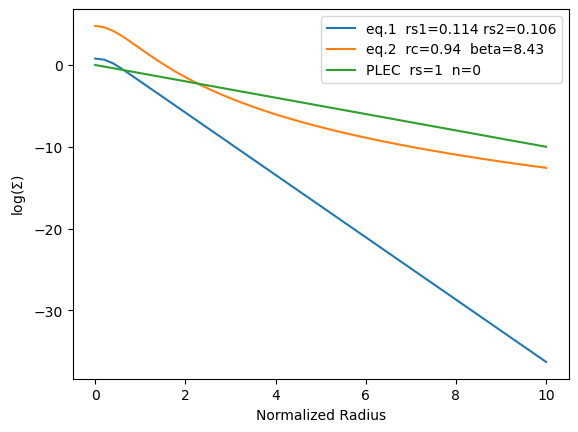

In [62]:
plt.plot(r,y1, label=f"eq.1  rs1={rs1} rs2={rs2}")
plt.plot(r,y2, label=f"eq.2  rc={rc}  beta={beta}")
plt.plot(r,y3, label=f"PLEC  rs={rs}  n={n}")
plt.xlabel("Normalized Radius")
plt.ylabel("log($\Sigma$)")
plt.legend()

## URC  Persic vs. Level5

```
nemoinp 0.1:2:0.1 | tabmath - - '0.72+0.44*log(%1),1+1.5*%1**0.2,1.6*exp(-0.4*%1),(1-%2)*(1+%3**2)' | tabplot - 1 2,3,4,5 line=1,1 color=2,3,4,5


for i in $(seq 20); do
 lbs=$(nemoinp $i/5)
 p=$(printf %02d $i)
 rotcurves persic 0,1,1,$lbs,1 radii=0:2:0.02 tab=t > persic_$p.tab
done
 
paste persic_??.tab | tabcols - 1,2:40:2 > persic1.tab
tabplot persic1.tab 1 2:20 0 2 0 1.2 line=1,1 
```